In [13]:
# Install required packages
# %pip install pandas numpy matplotlib seaborn scipy

# Imports
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

# Display settings
pd.set_option('display.max_columns', None)
pd.set_option('display.width', None)

# Load data
data = pd.read_csv("../data/raw/telco_customer_churn.csv")
print(f"Dataset shape: {data.shape}")
data.head()

Dataset shape: (7043, 21)


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [14]:
# Data Quality Check
print("=== Data Quality Check ===")
print(f"\nDataset Shape: {data.shape}")
print(f"\nMissing Values:\n{data.isnull().sum()}")
print(f"\nDuplicate Rows: {data.duplicated().sum()}")
print(f"\nData Types:\n{data.dtypes}")

=== Data Quality Check ===

Dataset Shape: (7043, 21)

Missing Values:
customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64

Duplicate Rows: 0

Data Types:
customerID              str
gender                  str
SeniorCitizen         int64
Partner                 str
Dependents              str
tenure                int64
PhoneService            str
MultipleLines           str
InternetService         str
OnlineSecurity          str
OnlineBackup            str
DeviceProtection        str
TechSupport             str
StreamingTV             str
StreamingMovies         str
Co

In [15]:
# Statistical Summary
print("=== Statistical Summary ===")
print(data.describe())

=== Statistical Summary ===
       SeniorCitizen       tenure  MonthlyCharges
count    7043.000000  7043.000000     7043.000000
mean        0.162147    32.371149       64.761692
std         0.368612    24.559481       30.090047
min         0.000000     0.000000       18.250000
25%         0.000000     9.000000       35.500000
50%         0.000000    29.000000       70.350000
75%         0.000000    55.000000       89.850000
max         1.000000    72.000000      118.750000


=== Target Variable Analysis ===
Churn Distribution:
Churn
No     5174
Yes    1869
Name: count, dtype: int64

Churn Percentage:
Churn
No     73.463013
Yes    26.536987
Name: proportion, dtype: float64


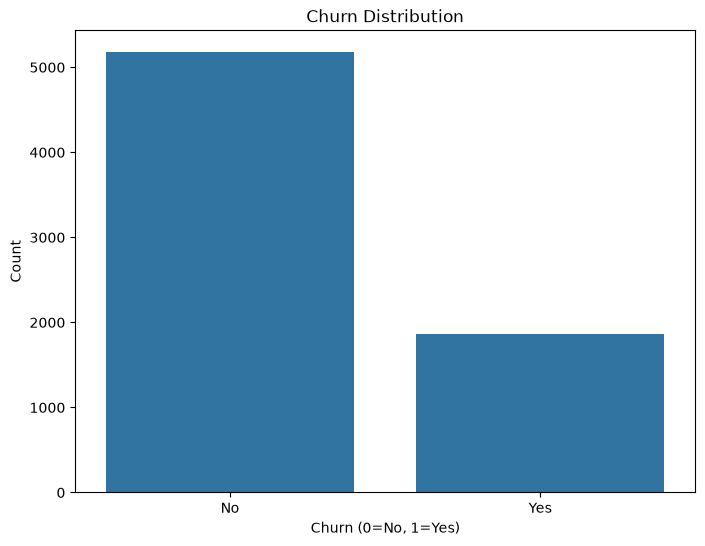

In [16]:
# Target Variable Analysis (Churn)
print("=== Target Variable Analysis ===")
churn_counts = data['Churn'].value_counts()
churn_pct = data['Churn'].value_counts(normalize=True) * 100

print(f"Churn Distribution:\n{churn_counts}")
print(f"\nChurn Percentage:\n{churn_pct}")

# Visualize churn distribution
fig, ax = plt.subplots(figsize=(8, 6))
sns.countplot(x='Churn', data=data, ax=ax)
ax.set_title('Churn Distribution')
ax.set_xlabel('Churn (0=No, 1=Yes)')
ax.set_ylabel('Count')
plt.show()

=== Univariate Analysis - Numerical Features ===


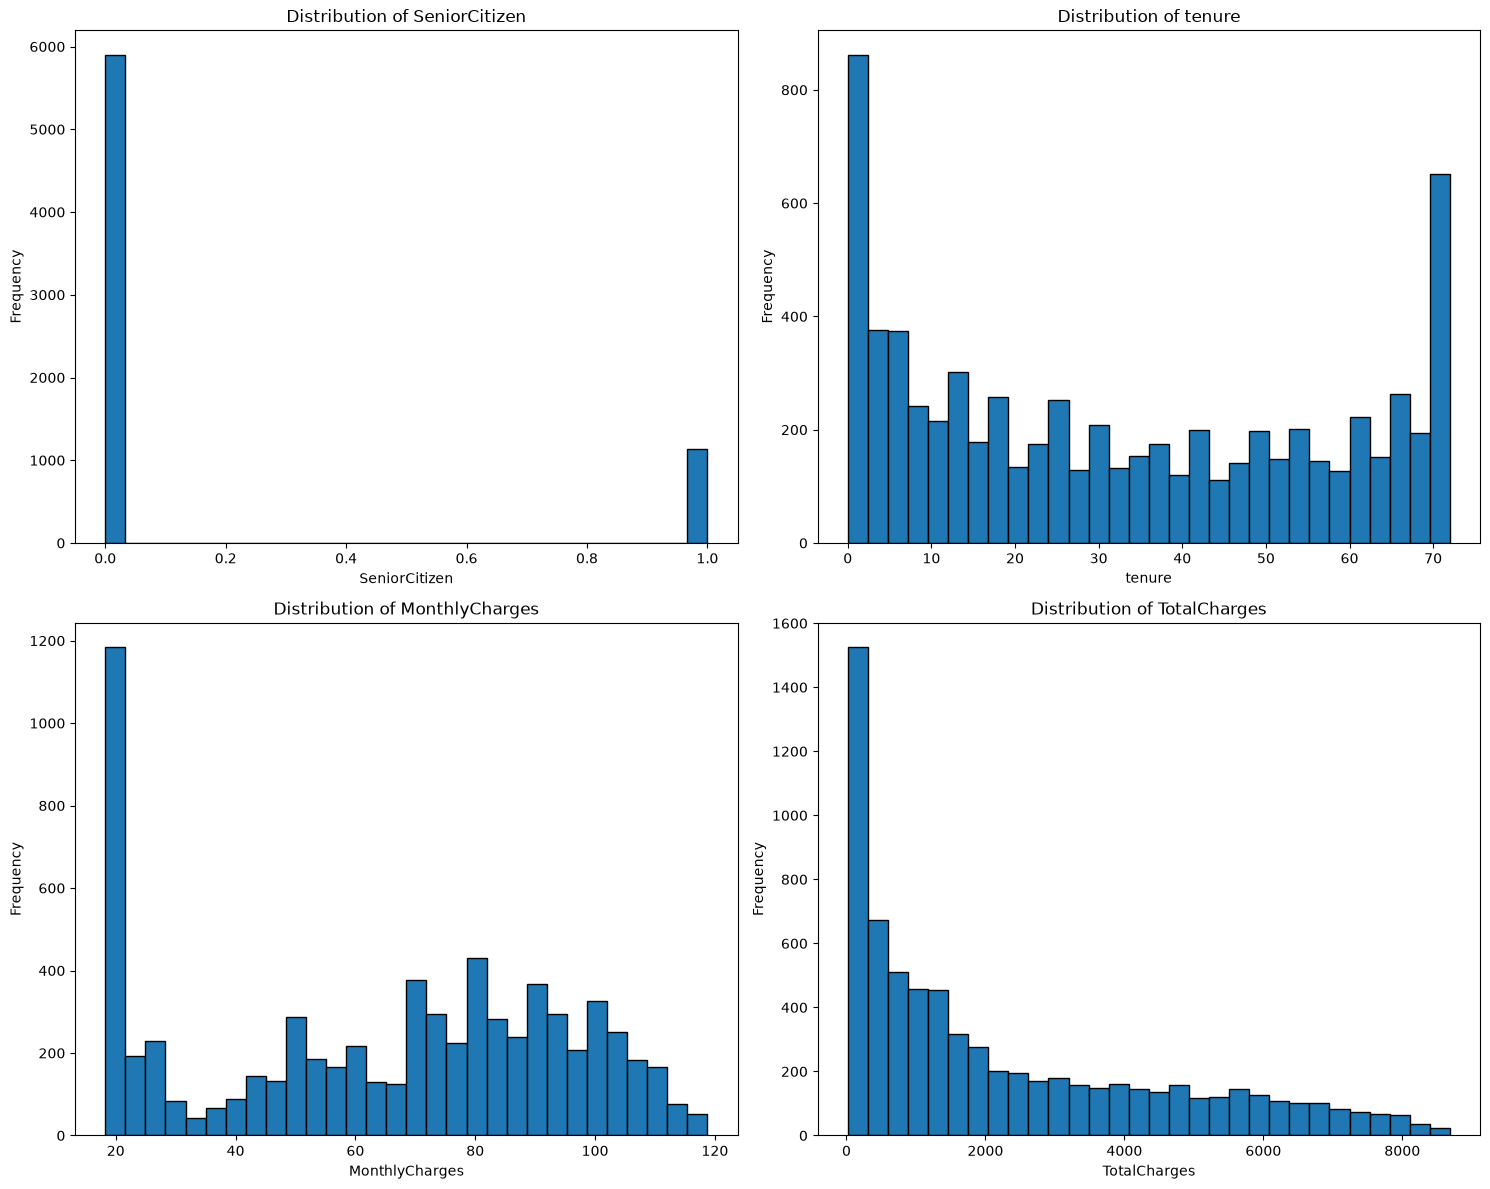

In [17]:
# Univariate Analysis - Numerical Features
print("=== Univariate Analysis - Numerical Features ===")

# Convert TotalCharges from string to numeric
data['TotalCharges'] = pd.to_numeric(data['TotalCharges'], errors='coerce')

numerical_cols = ['SeniorCitizen', 'tenure', 'MonthlyCharges', 'TotalCharges']

fig, axes = plt.subplots(2, 2, figsize=(15, 12))
axes = axes.ravel()

for idx, col in enumerate(numerical_cols):
    if idx < len(axes):
        axes[idx].hist(data[col].dropna(), bins=30, edgecolor='black')
        axes[idx].set_title(f'Distribution of {col}')
        axes[idx].set_xlabel(col)
        axes[idx].set_ylabel('Frequency')

plt.tight_layout()
plt.show()

=== Univariate Analysis - Categorical Features ===


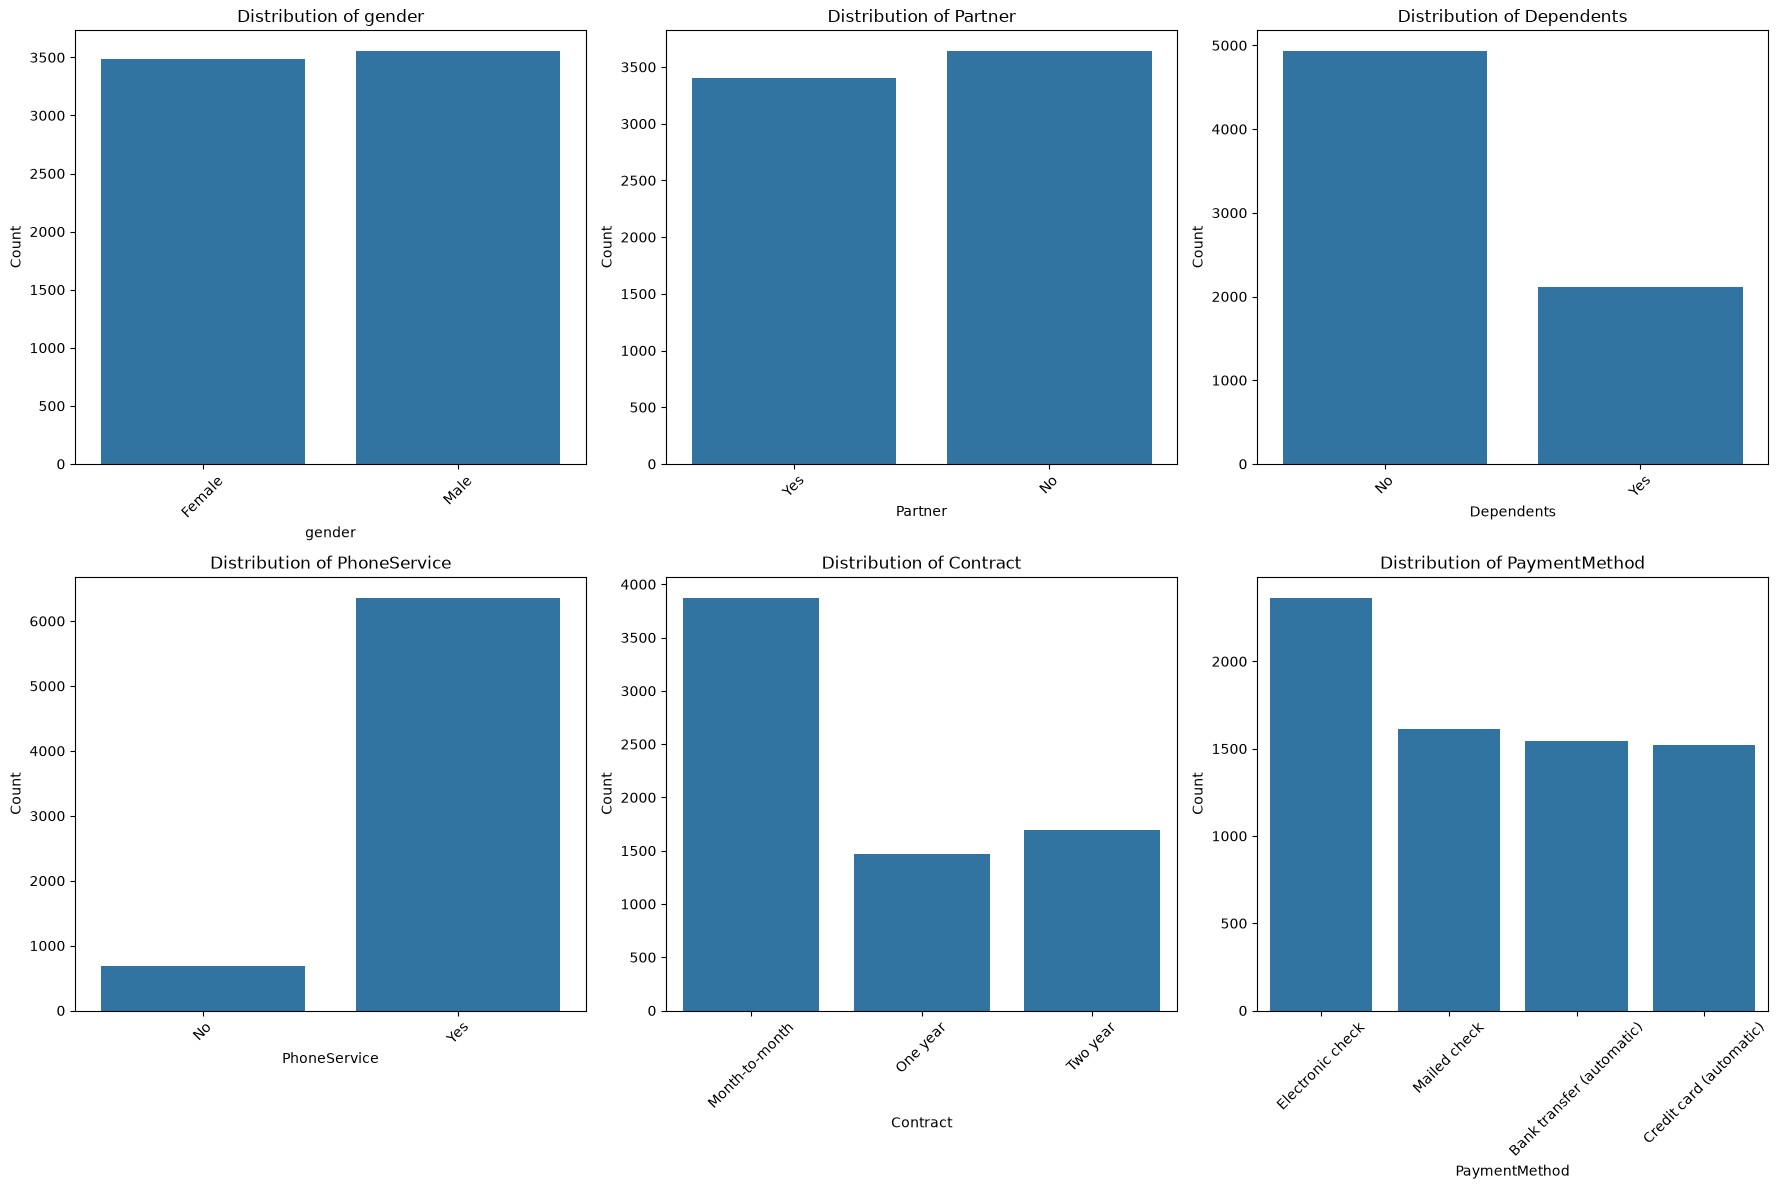


gender value counts:
gender
Male      3555
Female    3488
Name: count, dtype: int64
Percentages:
gender
Male      50.47565
Female    49.52435
Name: proportion, dtype: float64

Partner value counts:
Partner
No     3641
Yes    3402
Name: count, dtype: int64
Percentages:
Partner
No     51.69672
Yes    48.30328
Name: proportion, dtype: float64

Dependents value counts:
Dependents
No     4933
Yes    2110
Name: count, dtype: int64
Percentages:
Dependents
No     70.041176
Yes    29.958824
Name: proportion, dtype: float64

PhoneService value counts:
PhoneService
Yes    6361
No      682
Name: count, dtype: int64
Percentages:
PhoneService
Yes    90.316626
No      9.683374
Name: proportion, dtype: float64

Contract value counts:
Contract
Month-to-month    3875
Two year          1695
One year          1473
Name: count, dtype: int64
Percentages:
Contract
Month-to-month    55.019168
Two year          24.066449
One year          20.914383
Name: proportion, dtype: float64

PaymentMethod value counts:

In [18]:
# Univariate Analysis - Categorical Features
print("=== Univariate Analysis - Categorical Features ===")

categorical_cols = ['gender', 'Partner', 'Dependents', 'PhoneService', 'Contract', 'PaymentMethod']

fig, axes = plt.subplots(2, 3, figsize=(18, 12))
axes = axes.ravel()

for idx, col in enumerate(categorical_cols):
    if idx < len(axes):
        sns.countplot(x=col, data=data, ax=axes[idx])
        axes[idx].set_title(f'Distribution of {col}')
        axes[idx].set_xlabel(col)
        axes[idx].set_ylabel('Count')
        axes[idx].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

# Print value counts
for col in categorical_cols:
    print(f"\n{col} value counts:")
    print(data[col].value_counts())
    print(f"Percentages:\n{data[col].value_counts(normalize=True) * 100}")  # type: ignore

=== Bivariate Analysis - Numerical Features vs Churn ===


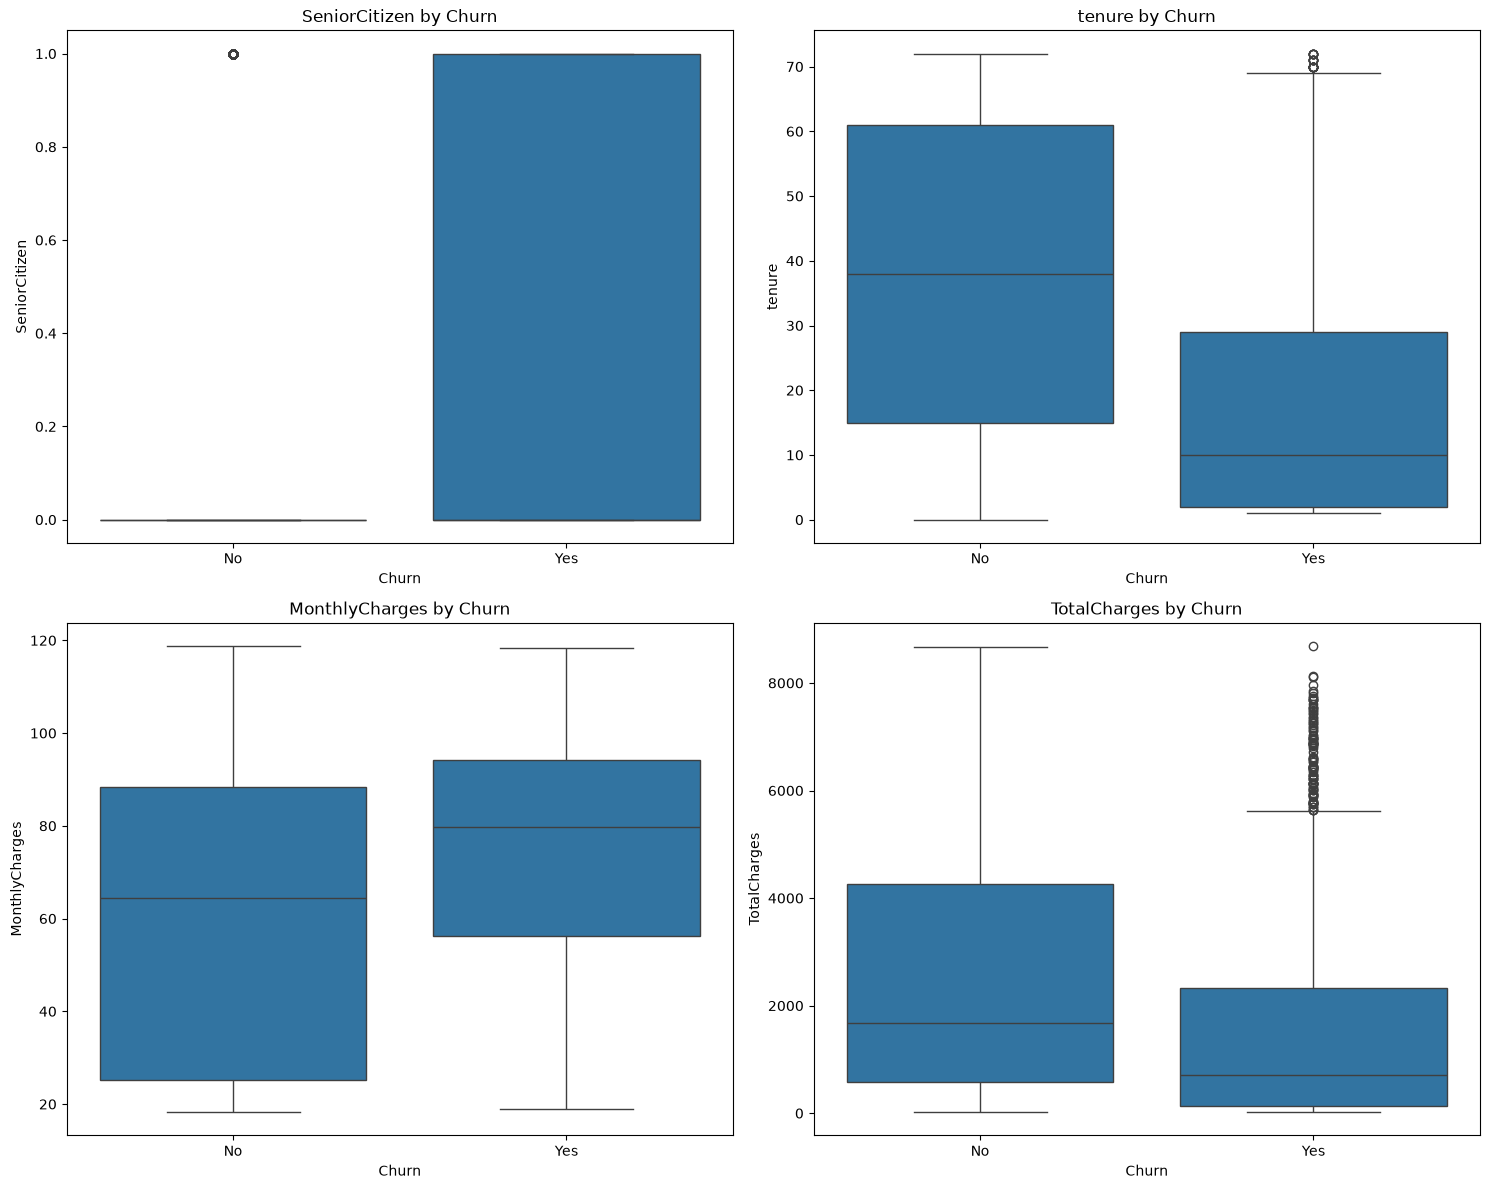

In [19]:
# Bivariate Analysis - Numerical Features vs Churn
print("=== Bivariate Analysis - Numerical Features vs Churn ===")

fig, axes = plt.subplots(2, 2, figsize=(15, 12))
axes = axes.ravel()

for idx, col in enumerate(numerical_cols):
    if idx < len(axes):
        sns.boxplot(x='Churn', y=col, data=data, ax=axes[idx])
        axes[idx].set_title(f'{col} by Churn')
        axes[idx].set_xlabel('Churn')
        axes[idx].set_ylabel(col)

plt.tight_layout()
plt.show()

=== Bivariate Analysis - Categorical Features vs Churn ===


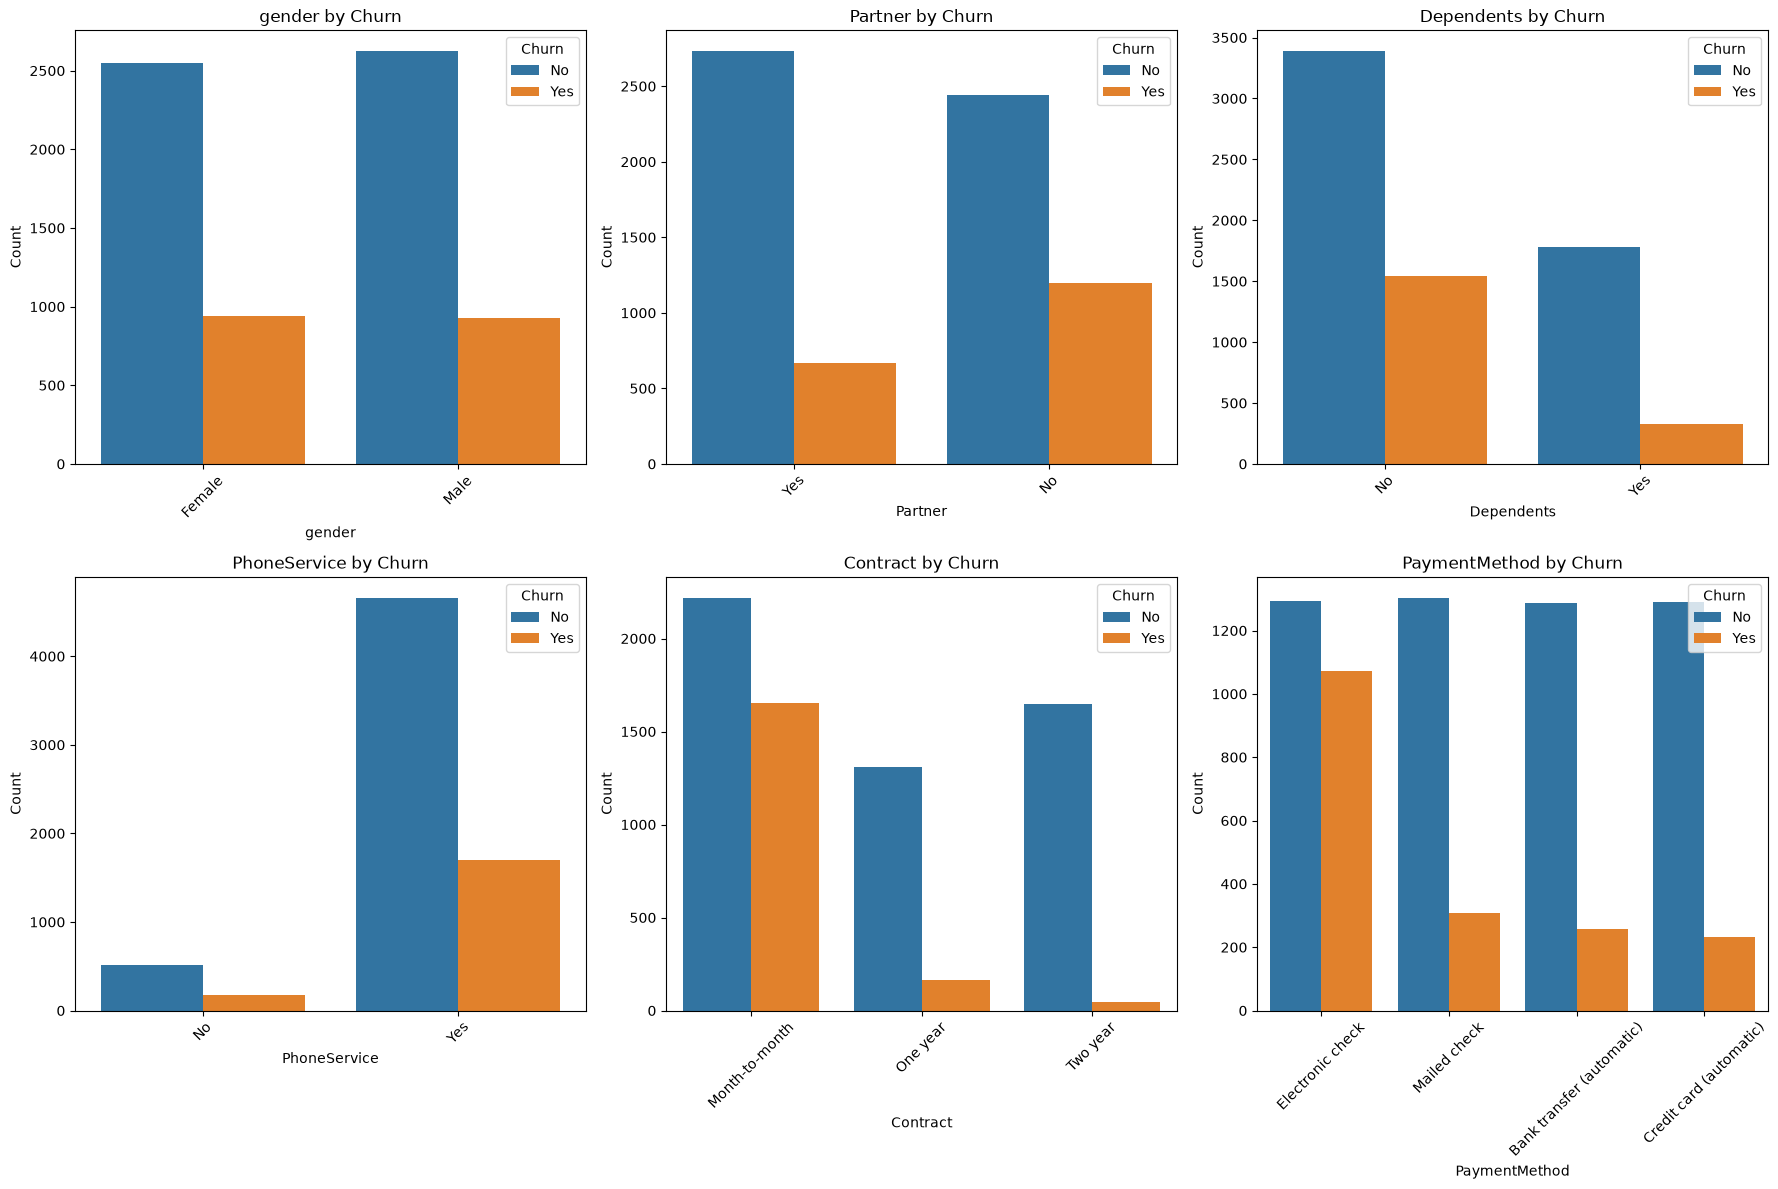


Churn rate by gender:
gender
Female    26.920872
Male      26.160338
Name: ChurnNumeric, dtype: float64

Churn rate by Partner:
Partner
No     32.957979
Yes    19.664903
Name: ChurnNumeric, dtype: float64

Churn rate by Dependents:
Dependents
No     31.279140
Yes    15.450237
Name: ChurnNumeric, dtype: float64

Churn rate by PhoneService:
PhoneService
No     24.926686
Yes    26.709637
Name: ChurnNumeric, dtype: float64

Churn rate by Contract:
Contract
Month-to-month    42.709677
One year          11.269518
Two year           2.831858
Name: ChurnNumeric, dtype: float64

Churn rate by PaymentMethod:
PaymentMethod
Bank transfer (automatic)    16.709845
Credit card (automatic)      15.243101
Electronic check             45.285412
Mailed check                 19.106700
Name: ChurnNumeric, dtype: float64


In [20]:
# Bivariate Analysis - Categorical Features vs Churn
print("=== Bivariate Analysis - Categorical Features vs Churn ===")

fig, axes = plt.subplots(2, 3, figsize=(18, 12))
axes = axes.ravel()

for idx, col in enumerate(categorical_cols):
    if idx < len(axes):
        sns.countplot(x=col, hue='Churn', data=data, ax=axes[idx])
        axes[idx].set_title(f'{col} by Churn')
        axes[idx].set_xlabel(col)
        axes[idx].set_ylabel('Count')
        axes[idx].tick_params(axis='x', rotation=45)
        axes[idx].legend(title='Churn', labels=['No', 'Yes'])

plt.tight_layout()
plt.show()

# Calculate churn rates by category
# Add numeric churn column to dataframe
data['ChurnNumeric'] = data['Churn'].apply(lambda x: 1 if x == 'Yes' else 0)

for col in categorical_cols:
    print(f"\nChurn rate by {col}:")
    churn_rate = data.groupby(col)['ChurnNumeric'].mean() * 100  # type: ignore
    print(churn_rate)

=== Churn Rate Breakdown by Key Features ===

Churn rate by Contract:
       segment  count  churned  churn_rate_%
Month-to-month   3875     1655         42.71
      One year   1473      166         11.27
      Two year   1695       48          2.83

Churn rate by TenureBand:
segment  count  churned  churn_rate_%
   0-12   2186     1037         47.44
  13-24   1024      294         28.71
  25-48   1594      325         20.39
  49-72   2239      213          9.51

Churn rate by PaymentMethod:
                  segment  count  churned  churn_rate_%
Bank transfer (automatic)   1544      258         16.71
  Credit card (automatic)   1522      232         15.24
         Electronic check   2365     1071         45.29
             Mailed check   1612      308         19.11


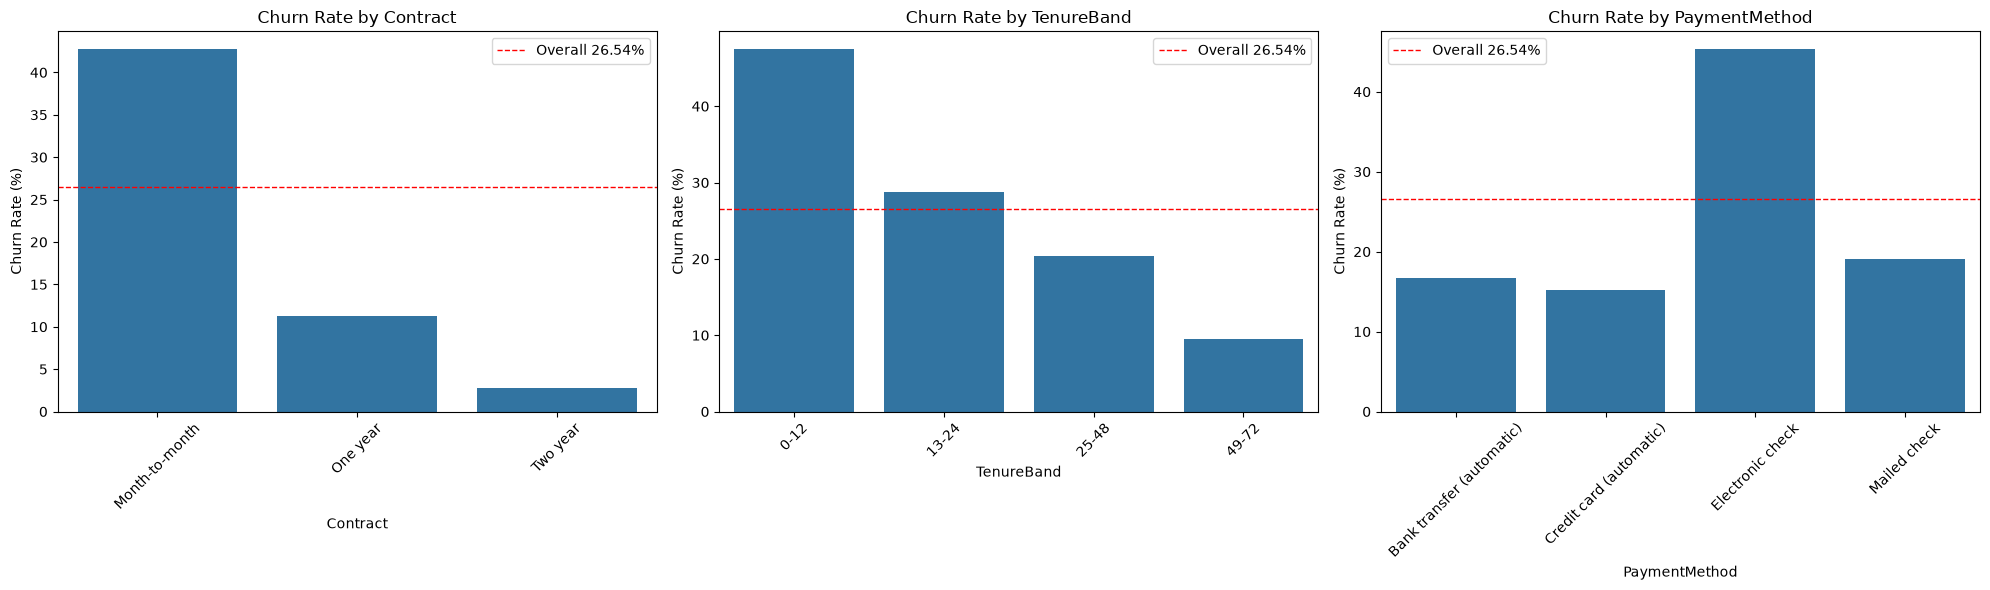

In [21]:
# Churn Rate Breakdown by Key Features (Contract, tenure band, PaymentMethod)
print("=== Churn Rate Breakdown by Key Features ===")

# Ensure numeric churn column exists (0/1)
data['ChurnNumeric'] = (data['Churn'] == 'Yes').astype(int)

# Bucket tenure into interpretable bands (months)
tenure_bins = [0, 12, 24, 48, 72]
tenure_labels = ['0-12', '13-24', '25-48', '49-72']
data['TenureBand'] = pd.cut(
    data['tenure'], bins=tenure_bins, labels=tenure_labels, include_lowest=True
)


def churn_breakdown(df: pd.DataFrame, feature: str) -> pd.DataFrame:
    """Return count, churned count, and churn rate (%) per segment of `feature`."""
    grouped = df.groupby(feature, observed=True)['ChurnNumeric']
    table = grouped.agg(count='size', churned='sum')
    table['churn_rate_%'] = (table['churned'] / table['count'] * 100).round(2)
    return table.reset_index().rename(columns={feature: 'segment'})


breakdown_features = ['Contract', 'TenureBand', 'PaymentMethod']
breakdowns = {}
for feat in breakdown_features:
    bd = churn_breakdown(data, feat)
    breakdowns[feat] = bd
    print(f"\nChurn rate by {feat}:")
    print(bd.to_string(index=False))

# Visualize churn rate (%) for each key feature
fig, axes = plt.subplots(1, 3, figsize=(20, 6))
for ax, feat in zip(axes, breakdown_features):
    bd = breakdowns[feat]
    sns.barplot(x='segment', y='churn_rate_%', data=bd, ax=ax)
    ax.axhline(26.54, color='red', linestyle='--', linewidth=1, label='Overall 26.54%')
    ax.set_title(f'Churn Rate by {feat}')
    ax.set_xlabel(feat)
    ax.set_ylabel('Churn Rate (%)')
    ax.tick_params(axis='x', rotation=45)
    ax.legend()

plt.tight_layout()
plt.show()

=== Correlation Analysis ===
Correlation Matrix:
                SeniorCitizen    tenure  MonthlyCharges  TotalCharges
SeniorCitizen        1.000000  0.016567        0.220173      0.102411
tenure               0.016567  1.000000        0.247900      0.825880
MonthlyCharges       0.220173  0.247900        1.000000      0.651065
TotalCharges         0.102411  0.825880        0.651065      1.000000

Saved correlation heatmap to ../results/correlation_heatmap.png


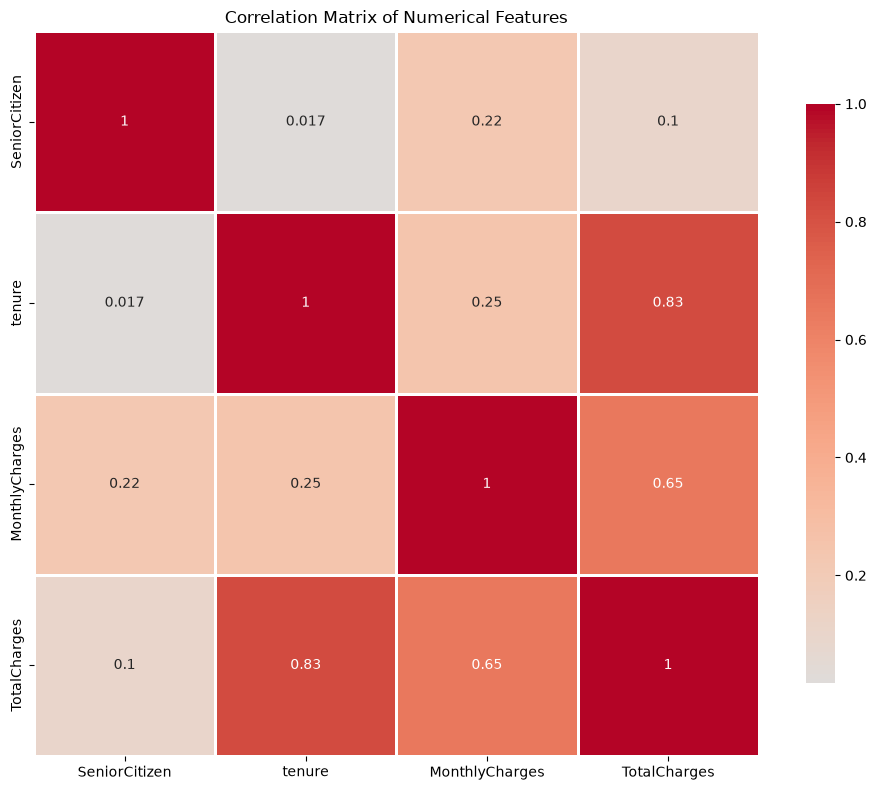

In [22]:
# Correlation Analysis
print("=== Correlation Analysis ===")

from pathlib import Path

# Output directory for saved figures
results_dir = Path("../results")
results_dir.mkdir(parents=True, exist_ok=True)

# Select only numerical columns for correlation
numerical_data = data[numerical_cols].copy()

# Calculate correlation matrix
correlation_matrix = numerical_data.corr()

# Display correlation matrix
print("Correlation Matrix:")
print(correlation_matrix)

# Visualize correlation matrix
plt.figure(figsize=(10, 8))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', center=0, 
            square=True, linewidths=1, cbar_kws={"shrink": 0.8})
plt.title('Correlation Matrix of Numerical Features')
plt.tight_layout()

# Save heatmap to results/
heatmap_path = results_dir / "correlation_heatmap.png"
plt.savefig(heatmap_path, dpi=150, bbox_inches='tight')
print(f"\nSaved correlation heatmap to {heatmap_path}")

plt.show()

In [23]:
# Key Insights Summary
print("=== Key Insights Summary ===")

print("""
Based on the exploratory data analysis:

1. DATASET OVERVIEW:
   - Total records: 7,043
   - 21 features: 4 numerical, 16 categorical, 1 target
   - Churn rate: 26.5% (imbalanced dataset)

2. DATA QUALITY:
   - No missing values in the dataset
   - No duplicate rows found
   - TotalCharges stored as string, converted to numeric
   - Clean dataset overall

3. TARGET VARIABLE:
   - Churn is imbalanced (26.5% churn vs 73.5% non-churn)
   - May require techniques like SMOTE or class weights in modeling

4. CATEGORICAL FEATURES:
   - Contract: Month-to-month (55%), One year (21%), Two year (24%)
   - PaymentMethod: Electronic check (33.6%), Mailed check (22.8%), Bank transfer (21.9%), Credit card (21.6%)
   - InternetService: Fiber optic (44%), DSL (35%), No (21%)
   - gender: Approximately balanced

5. NUMERICAL FEATURES:
   - tenure: Mean 32.4 months, range 0-72
   - MonthlyCharges: Mean $64.76, range $18.25-$118.75
   - TotalCharges: Converted from string to numeric
   - SeniorCitizen: 16.2% are senior citizens

6. NEXT STEPS:
   - Analyze feature correlations with churn
   - Perform feature engineering
   - Handle class imbalance in modeling
   - Build and evaluate classification models
""")

=== Key Insights Summary ===

Based on the exploratory data analysis:

1. DATASET OVERVIEW:
   - Total records: 7,043
   - 21 features: 4 numerical, 16 categorical, 1 target
   - Churn rate: 26.5% (imbalanced dataset)

2. DATA QUALITY:
   - No missing values in the dataset
   - No duplicate rows found
   - TotalCharges stored as string, converted to numeric
   - Clean dataset overall

3. TARGET VARIABLE:
   - Churn is imbalanced (26.5% churn vs 73.5% non-churn)
   - May require techniques like SMOTE or class weights in modeling

4. CATEGORICAL FEATURES:
   - Contract: Month-to-month (55%), One year (21%), Two year (24%)
   - PaymentMethod: Electronic check (33.6%), Mailed check (22.8%), Bank transfer (21.9%), Credit card (21.6%)
   - InternetService: Fiber optic (44%), DSL (35%), No (21%)
   - gender: Approximately balanced

5. NUMERICAL FEATURES:
   - tenure: Mean 32.4 months, range 0-72
   - MonthlyCharges: Mean $64.76, range $18.25-$118.75
   - TotalCharges: Converted from string to